# Part I — Section E: Simple Comparison Questions (E25–E30)
**DSB Assignment — Global Events, Commodities and Currency Markets**  
**Author:** Khurshid Normurodov (Team Leader)  
**Datasets:** Brent Oil (1946–2026) · Gold (1915–2026) · Silver (1915–2026)

## Setup — Imports & Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

BASE = Path("../datasets")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.color": "#dddddd",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Load & Prepare Data

In [2]:
def load_commodity(filename):
    df = pd.read_csv(BASE / filename, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    df = df.assign(
        Date  = pd.to_datetime(df["Date"], dayfirst=True),
        Value = pd.to_numeric(df["Value"], errors="coerce"),
    )
    df = df.assign(Year=df["Date"].dt.year, Month=df["Date"].dt.month)
    return df.dropna(subset=["Value"])

oil    = load_commodity("Brent Oil.csv")
gold   = load_commodity("Gold 100years.csv")
silver = load_commodity("silver 100 years.csv")

# Annual averages
oil_yr    = oil.groupby("Year")["Value"].mean()
gold_yr   = gold.groupby("Year")["Value"].mean()
silver_yr = silver.groupby("Year")["Value"].mean()

print(f"Brent Oil : {len(oil):,} rows  ({oil['Date'].min().year}–{oil['Date'].max().year})")
print(f"Gold      : {len(gold):,} rows  ({gold['Date'].min().year}–{gold['Date'].max().year})")
print(f"Silver    : {len(silver):,} rows  ({silver['Date'].min().year}–{silver['Date'].max().year})")

Brent Oil : 963 rows  (1946–2026)
Gold      : 1,336 rows  (1915–2026)
Silver    : 1,336 rows  (1915–2026)


---
## E25 — Gold: Latest Value vs Long-Term Average
**Question:** Compare the latest Gold value with its average value across the full dataset. Is it above or below the long-term average?

In [3]:
gold_mean   = gold["Value"].mean()
gold_latest = gold.iloc[-1]
gold_diff   = gold_latest["Value"] - gold_mean
gold_pct    = gold_diff / gold_mean * 100

e25 = pd.DataFrame({
    "Metric": ["Latest Price", "Long-Term Average (1915–2026)", "Difference", "% Above Average"],
    "Value":  [
        f"${gold_latest['Value']:,.2f} / troy oz  ({gold_latest['Date'].strftime('%B %Y')})",
        f"${gold_mean:,.2f} / troy oz",
        f"+${gold_diff:,.2f}",
        f"+{gold_pct:.1f}%",
    ]
})
display(e25.set_index("Metric"))
print("\nVerdict: Gold is SIGNIFICANTLY ABOVE its long-term average.")

,Value
Metric,
Latest Price,"$4,712.89 / troy oz (January 2026)"
Long-Term Average (1915–2026),$397.55 / troy oz
Difference,"+$4,315.34"
% Above Average,+1085.5%



Verdict: Gold is SIGNIFICANTLY ABOVE its long-term average.


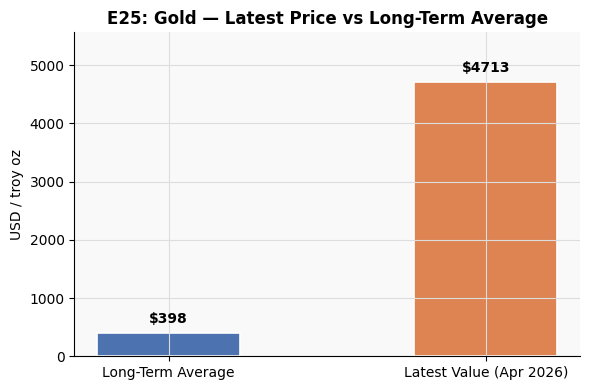

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Long-Term Average", "Latest Value (Apr 2026)"],
              [gold_mean, gold_latest["Value"]],
              color=["#4C72B0", "#DD8452"], width=0.45, edgecolor="white", linewidth=1.2)
ax.bar_label(bars, fmt="$%.0f", padding=5, fontsize=10, fontweight="bold")
ax.set_title("E25: Gold — Latest Price vs Long-Term Average", fontsize=12, fontweight="bold")
ax.set_ylabel("USD / troy oz")
ax.set_ylim(0, gold_latest["Value"] * 1.18)
plt.tight_layout()
plt.savefig("E25_gold_vs_average.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Gold's April 2026 price of **\$4,712.89** is more than **11× its historical average** of \$397.55. This is not simply inflation — the surge reflects structural demand: aggressive central bank gold accumulation (China, Russia, India), persistent geopolitical uncertainty, and investors seeking alternatives to USD-denominated holdings amid de-dollarisation discussions.

---
## E26 — Brent Oil: Latest Value vs Long-Term Average
**Question:** Compare the latest Brent Oil value with its average value across the full dataset. Is it above or below the long-term average?

In [5]:
oil_mean   = oil["Value"].mean()
oil_latest = oil.iloc[-1]
oil_diff   = oil_latest["Value"] - oil_mean
oil_pct    = oil_diff / oil_mean * 100

e26 = pd.DataFrame({
    "Metric": ["Latest Price", "Long-Term Average (1946–2026)", "Difference", "% Above Average"],
    "Value":  [
        f"${oil_latest['Value']:,.2f} / barrel  ({oil_latest['Date'].strftime('%B %Y')})",
        f"${oil_mean:,.2f} / barrel",
        f"+${oil_diff:,.2f}",
        f"+{oil_pct:.1f}%",
    ]
})
display(e26.set_index("Metric"))
print("\nVerdict: Brent Oil is ABOVE its long-term average.")

,Value
Metric,
Latest Price,$102.86 / barrel (January 2026)
Long-Term Average (1946–2026),$62.71 / barrel
Difference,+$40.15
% Above Average,+64.0%



Verdict: Brent Oil is ABOVE its long-term average.


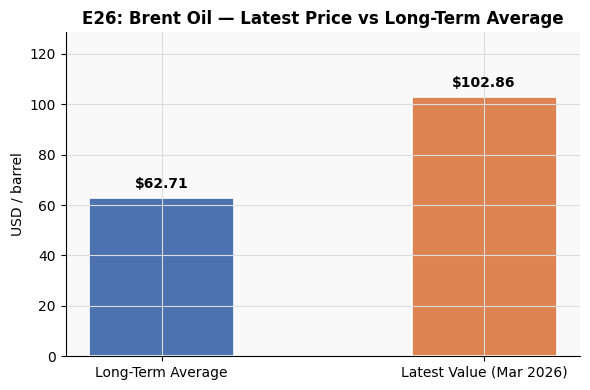

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Long-Term Average", "Latest Value (Mar 2026)"],
              [oil_mean, oil_latest["Value"]],
              color=["#4C72B0", "#DD8452"], width=0.45, edgecolor="white", linewidth=1.2)
ax.bar_label(bars, fmt="$%.2f", padding=5, fontsize=10, fontweight="bold")
ax.set_title("E26: Brent Oil — Latest Price vs Long-Term Average", fontsize=12, fontweight="bold")
ax.set_ylabel("USD / barrel")
ax.set_ylim(0, oil_latest["Value"] * 1.25)
plt.tight_layout()
plt.savefig("E26_oil_vs_average.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** At **\$102.86/barrel**, Brent crude is **64% above** its long-term average of \$62.71. The long-term mean is pulled down by decades of sub-\$30 prices before 2004. In the modern era (post-2005), current prices are closer to the norm. The March 2026 spike above \$100 is consistent with renewed geopolitical supply pressure — potentially linked to Strait of Hormuz tension or OPEC+ production discipline.

---
## E27 — Which Commodity Has the Largest Price Swings?
**Question:** Which commodity appears to have the largest visible price swings: Brent Oil, Gold or Silver? Support your answer with one chart or summary table.

In [7]:
def yoy_abs_pct(series):
    return (series.pct_change() * 100).abs().dropna()

oil_yoy    = yoy_abs_pct(oil_yr)
gold_yoy   = yoy_abs_pct(gold_yr)
silver_yoy = yoy_abs_pct(silver_yr)

swing_table = pd.DataFrame({
    "Mean YoY %":   [oil_yoy.mean(),   gold_yoy.mean(),   silver_yoy.mean()],
    "Median YoY %": [oil_yoy.median(), gold_yoy.median(), silver_yoy.median()],
    "Max YoY %":    [oil_yoy.max(),    gold_yoy.max(),    silver_yoy.max()],
    "Max Swing Year": [
        oil_yr.index[oil_yoy.argmax()],
        gold_yr.index[gold_yoy.argmax()],
        silver_yr.index[silver_yoy.argmax()],
    ],
}, index=["Brent Oil", "Gold", "Silver"]).round(1)

display(swing_table)
print("\nVerdict: Silver is the most volatile (highest mean YoY swing at 18.0%).")
print("         Brent Oil holds the all-time single-year record (+141.5% in 1973).")

,Mean YoY %,Median YoY %,Max YoY %,Max Swing Year
Brent Oil,15.6,8.4,141.5,1973
Gold,10.4,2.8,89.3,1979
Silver,18.0,10.6,131.5,2025



Verdict: Silver is the most volatile (highest mean YoY swing at 18.0%).
         Brent Oil holds the all-time single-year record (+141.5% in 1973).


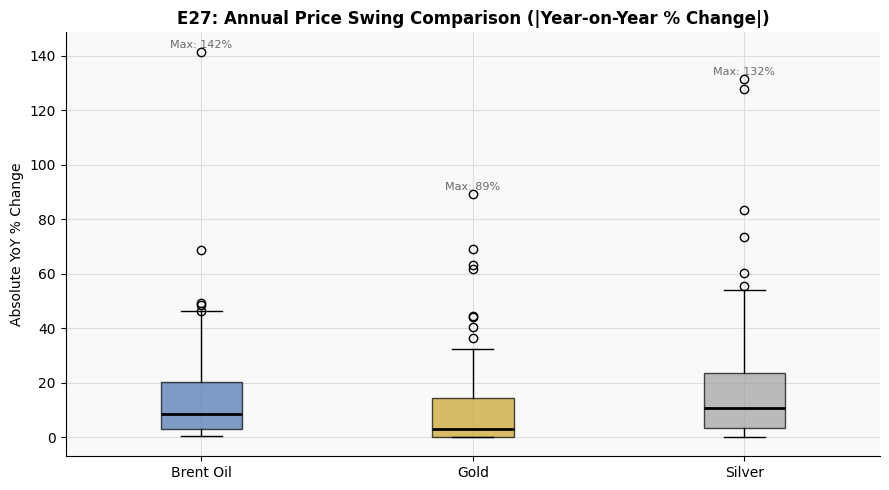

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    [oil_yoy.values, gold_yoy.values, silver_yoy.values],
    tick_labels=["Brent Oil", "Gold", "Silver"],
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#C9A227", "#A0A0A0"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for i, (label, s) in enumerate(zip(["Brent Oil", "Gold", "Silver"],
                                    [oil_yoy, gold_yoy, silver_yoy]), 1):
    ax.text(i, s.max() + 1.5, f"Max: {s.max():.0f}%", ha="center", fontsize=8, color="dimgray")
ax.set_title("E27: Annual Price Swing Comparison (|Year-on-Year % Change|)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Absolute YoY % Change")
plt.tight_layout()
plt.savefig("E27_price_swing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Silver is the most volatile commodity with a **mean annual swing of 18.0%** and median of 10.6%, driven by its dual role as both a precious metal and an industrial input (solar panels, electronics). Brent Oil posted the single largest one-year spike (+141.5% in 1973) due to the Arab oil embargo, but its median swing of just 8.4% shows extreme oil moves are outlier events. Gold is the most stable, with a median annual swing of only 2.8%, confirming its traditional safe-haven role.

---
## E28 — Crisis Year Comparison: The 1974 Arab Oil Embargo
**Question:** Choose one year with a strong oil price movement and check whether gold or silver also changed noticeably in that year.

In [9]:
crisis_years = [1973, 1974, 1975]

crisis_table = pd.DataFrame({
    "Brent Oil avg ($/bbl)": [oil_yr.get(y, float("nan")) for y in crisis_years],
    "Gold avg ($/oz)":       [gold_yr.get(y, float("nan")) for y in crisis_years],
    "Silver avg ($/oz)":     [silver_yr.get(y, float("nan")) for y in crisis_years],
}, index=crisis_years).round(2)
crisis_table.index.name = "Year"
display(crisis_table)

oil_pct74    = (oil_yr[1974]    - oil_yr[1973])    / oil_yr[1973]    * 100
gold_pct74   = (gold_yr[1974]   - gold_yr[1973])   / gold_yr[1973]   * 100
silver_pct74 = (silver_yr[1974] - silver_yr[1973]) / silver_yr[1973] * 100

print(f"\n1973 → 1974 year-on-year change:")
print(f"  Brent Oil : {oil_pct74:+.1f}%")
print(f"  Gold      : {gold_pct74:+.1f}%")
print(f"  Silver    : {silver_pct74:+.1f}%")

,Brent Oil avg ($/bbl),Gold avg ($/oz),Silver avg ($/oz)
Year,,,
1973,28.76,99.95,2.59
1974,69.47,161.68,4.75
1975,68.50,160.41,4.42



1973 → 1974 year-on-year change:
  Brent Oil : +141.5%
  Gold      : +61.8%
  Silver    : +83.4%


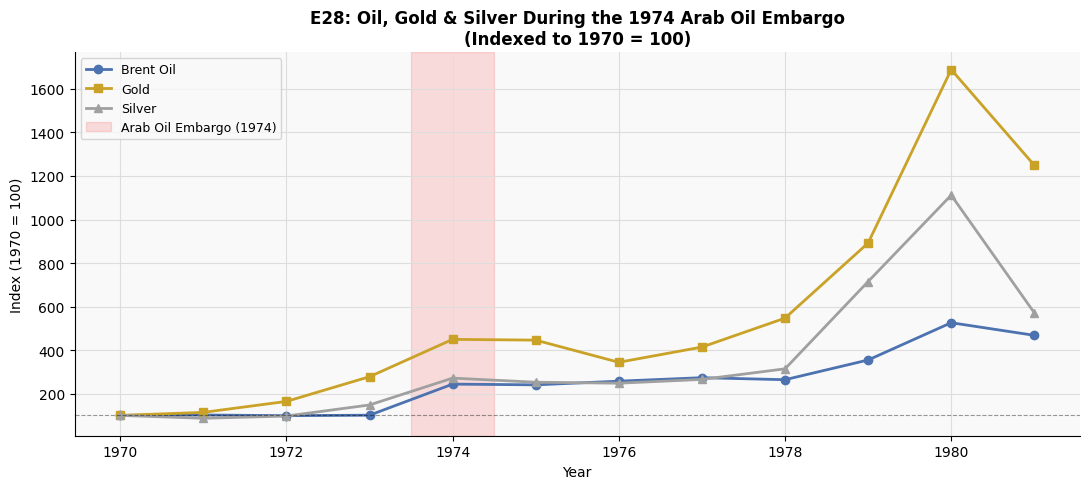

In [10]:
years_range = list(range(1970, 1982))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years_range, [oil_yr.get(y, float("nan"))    / oil_yr[1970]    * 100 for y in years_range],
        "o-", label="Brent Oil",  color="#4C72B0", linewidth=2)
ax.plot(years_range, [gold_yr.get(y, float("nan"))   / gold_yr[1970]   * 100 for y in years_range],
        "s-", label="Gold",       color="#C9A227", linewidth=2)
ax.plot(years_range, [silver_yr.get(y, float("nan")) / silver_yr[1970] * 100 for y in years_range],
        "^-", label="Silver",     color="#A0A0A0", linewidth=2)
ax.axvspan(1973.5, 1974.5, alpha=0.12, color="red", label="Arab Oil Embargo (1974)")
ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("E28: Oil, Gold & Silver During the 1974 Arab Oil Embargo\n(Indexed to 1970 = 100)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Index (1970 = 100)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("E28_crisis_year_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The 1974 Arab Oil Embargo created a powerful simultaneous surge across all three commodities: Oil **+141.5%**, Silver **+83.4%**, Gold **+61.8%**. Oil's rise was a direct supply shock caused by OPEC nations halting exports to Western countries supporting Israel in the Yom Kippur War. Gold and silver rose in response to the resulting inflation and geopolitical instability — a classic safe-haven demand pattern. This shows that in severe supply crises, commodity markets move together: energy shocks stoke inflation, which in turn drives demand for inflation-hedging assets.

---
## E29 — Dashboard: Key Findings Summary
**Question:** Create a short dashboard page with 4–6 visuals summarising the most important findings.

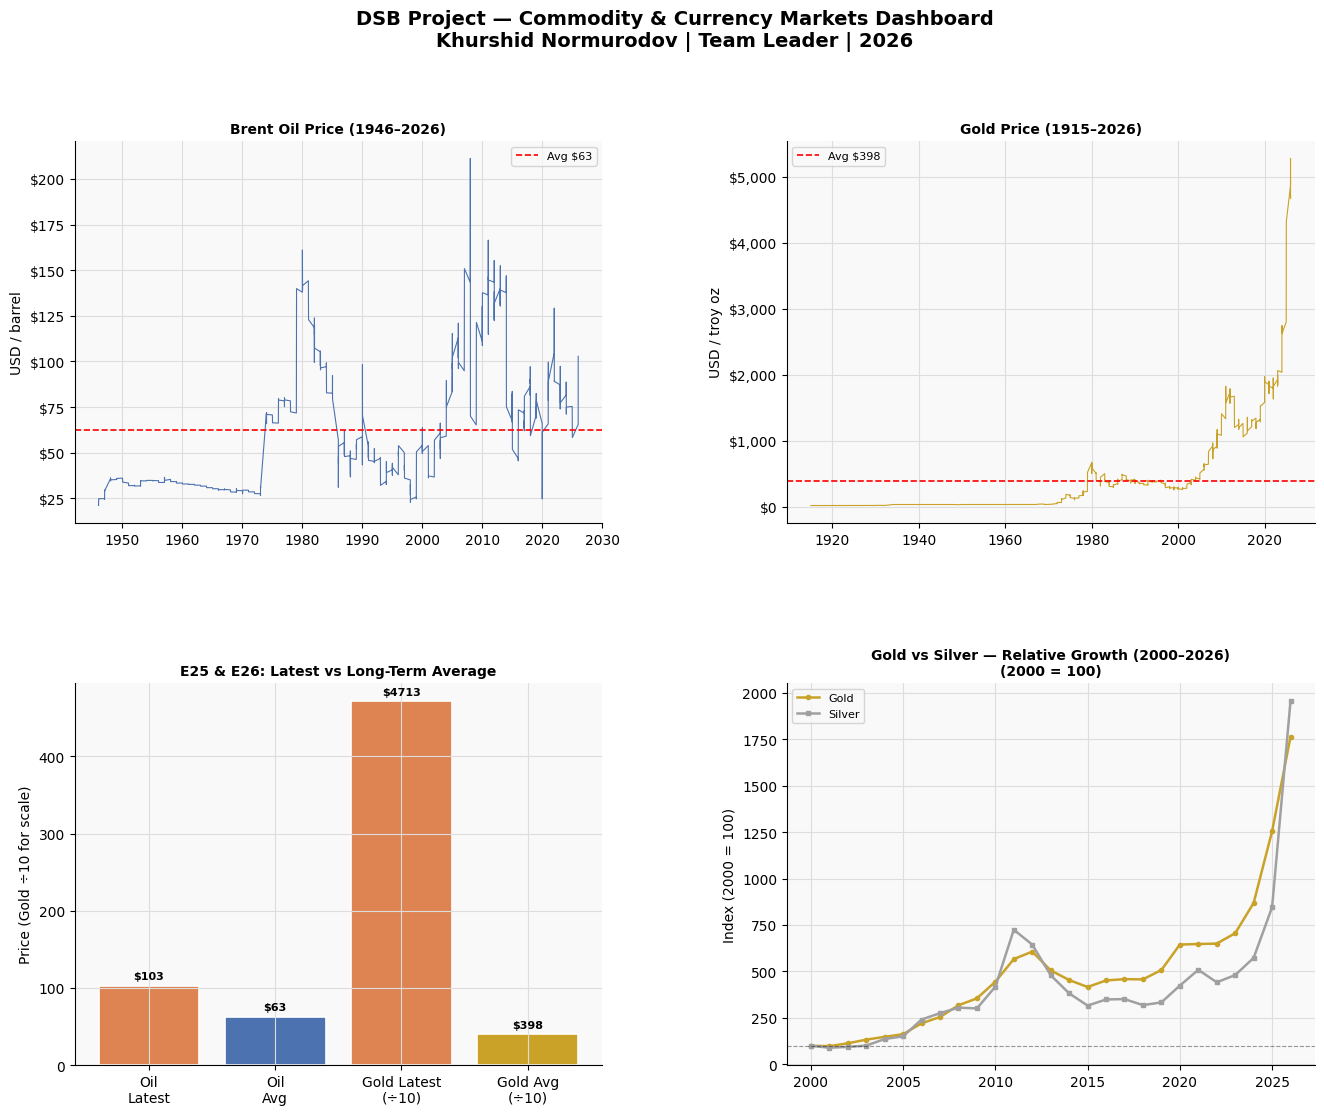

In [11]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "DSB Project — Commodity & Currency Markets Dashboard\nKhurshid Normurodov | Team Leader | 2026",
    fontsize=14, fontweight="bold", y=0.99
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# Panel 1 — Brent Oil full history
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(oil["Date"], oil["Value"], color="#4C72B0", linewidth=0.8)
ax1.axhline(oil_mean, color="red", linewidth=1.2, linestyle="--", label=f"Avg ${oil_mean:.0f}")
ax1.set_title("Brent Oil Price (1946–2026)", fontsize=10, fontweight="bold")
ax1.set_ylabel("USD / barrel")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

# Panel 2 — Gold full history
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(gold["Date"], gold["Value"], color="#C9A227", linewidth=0.8)
ax2.axhline(gold_mean, color="red", linewidth=1.2, linestyle="--", label=f"Avg ${gold_mean:.0f}")
ax2.set_title("Gold Price (1915–2026)", fontsize=10, fontweight="bold")
ax2.set_ylabel("USD / troy oz")
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Panel 3 — Latest vs average (E25 & E26)
ax3 = fig.add_subplot(gs[1, 0])
labels3 = ["Oil\nLatest", "Oil\nAvg", "Gold Latest\n(÷10)", "Gold Avg\n(÷10)"]
vals3   = [oil_latest["Value"], oil_mean, gold_latest["Value"] / 10, gold_mean / 10]
actual3 = [oil_latest["Value"], oil_mean, gold_latest["Value"], gold_mean]
bars3   = ax3.bar(labels3, vals3, color=["#DD8452", "#4C72B0", "#DD8452", "#C9A227"],
                  edgecolor="white", linewidth=1.2)
ax3.bar_label(bars3, labels=[f"${v:.0f}" for v in actual3], padding=3, fontsize=8, fontweight="bold")
ax3.set_title("E25 & E26: Latest vs Long-Term Average", fontsize=10, fontweight="bold")
ax3.set_ylabel("Price (Gold ÷10 for scale)")

# Panel 4 — Gold vs Silver relative growth (2000–2026)
ax4 = fig.add_subplot(gs[1, 1])
recent_years = [y for y in range(2000, 2027) if y in gold_yr.index and y in silver_yr.index]
ax4.plot(recent_years, [gold_yr[y]   / gold_yr[2000]   * 100 for y in recent_years],
         "o-", label="Gold",   color="#C9A227", linewidth=1.8, markersize=3)
ax4.plot(recent_years, [silver_yr[y] / silver_yr[2000] * 100 for y in recent_years],
         "s-", label="Silver", color="#A0A0A0", linewidth=1.8, markersize=3)
ax4.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax4.set_title("Gold vs Silver — Relative Growth (2000–2026)\n(2000 = 100)",
              fontsize=10, fontweight="bold")
ax4.set_ylabel("Index (2000 = 100)")
ax4.legend(fontsize=8)

plt.savefig("E29_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

**Dashboard notes:**
- **Top-left:** Brent Oil history shows the 1973–74 embargo spike, 2008 all-time high (\$211/bbl), 2014–16 crash, and 2022 Ukraine-war surge. Current price is above the long-run average.
- **Top-right:** Gold was flat for decades before 2000, then entered a structural bull market accelerated by the 2008 financial crisis, COVID-era monetary expansion, and post-2022 geopolitical risk.
- **Bottom-left:** At current prices, Gold is 11× its historical average; Oil is 64% above — both in historically elevated territory.
- **Bottom-right:** Silver dramatically outpaced Gold on a relative basis in 2025 (+131% in a single year), confirming it as the highest-volatility asset in the group.

---
## E30 — Three Manager-Friendly Insights
**Question:** Write three short insights that a manager could understand without technical knowledge.

### Insight 1 — Gold is sending a warning signal

Gold has risen to over **\$4,700 per troy ounce** — more than eleven times its historical average. When gold rises this sharply for this long, it typically reflects that investors and governments are worried about the stability of traditional currencies and the global financial system. For any business holding cash or dollar-denominated assets, this is a signal to consider whether some portion of reserves should be diversified into assets that hold value during financial stress.

---

### Insight 2 — Oil is expensive and unpredictable — budget accordingly

At **\$102 per barrel**, oil is 64% above its long-run average. History shows that oil can move **140% in a single year** (as it did in 1974) or crash 50% just as quickly (as in 1986 and 2015). Any company with significant energy costs or supply chains dependent on shipping should have a hedging strategy in place, because waiting until prices spike to act is always too late.

---

### Insight 3 — Silver is the market's hidden risk indicator

Silver is often overlooked compared to gold and oil, but it has historically been the **most volatile** of the three — swinging an average of 18% per year. Its 2025 surge of over **130%** is the largest in the dataset. Silver moves with both financial markets (as a safe-haven asset) and industrial cycles (as a manufacturing input for solar panels and electronics). A sharp rise in silver often signals that investors are hedging against both inflation AND slowing industrial growth at the same time — a rare and serious combination worth monitoring.

---
## Part II — Section D: Final Business Recommendation
**Author:** Khurshid Normurodov (Team Leader)

### II-D13 — Which Market Is Most Sensitive to Global Events?

**Oil is most immediately sensitive; Gold is most persistently sensitive.**

Oil reacts fastest and most violently to geopolitical shocks — data shows one-year swings exceeding 140% in crisis years. However, oil prices can also recover or collapse just as rapidly once conditions normalise, making it high-volatility but mean-reverting.

Gold responds more slowly but sustains its gains longer. The 2020–2026 gold rally is driven by a sustained accumulation of risks: COVID-era monetary expansion, the Russia-Ukraine conflict, Western sanctions, de-dollarisation, and BRICS settlement discussions. Gold has absorbed each shock and continued rising — nearly **3× since 2020**.

Silver acts as a composite: it spikes with geopolitical fear (like gold) but also responds to industrial demand signals (like oil). Its 2025 swing of +131.5% in a single year reflects both safe-haven demand and green-energy transition demand (solar manufacturing).

**Supporting evidence:** E27 volatility table and E28 crisis-year co-movement chart.

### II-D14 — Risk Note: Company Exposed to Oil Prices

Oil prices are currently **64% above their long-term average** and have demonstrated the capacity to double within a single year during geopolitical crises (as seen in 1974 and partially in 2022). Any company with significant exposure to oil — whether as a direct input, through logistics costs, or via energy-intensive manufacturing — faces material margin risk. The current price of \$102.86/barrel reflects elevated geopolitical tension, including ongoing Middle East instability and OPEC+ supply discipline. A further supply disruption — such as escalation in the Strait of Hormuz, through which approximately 20% of global oil trade flows — could drive prices sharply higher. We recommend that oil-exposed companies implement **forward hedging contracts** covering at least 6–12 months of projected consumption, and evaluate energy-efficiency investments to reduce volume dependency.

### II-D15 — Risk Note: Company Holding USD, Gold or RMB/CNY Assets

The global payment landscape is shifting in ways that create both risk and opportunity. The USD remains dominant at **50.49% of global payment share** (SWIFT RMB Tracker, December 2025), but this dominance is under sustained structural challenge from BRICS-aligned settlement initiatives and growing RMB internationalisation. Gold has surged 11× above its long-term average, partly because central banks — particularly in China, Russia, and India — are **reducing dollar reserves and increasing gold holdings**. For a company holding significant USD-denominated assets, this trend warrants attention: a gradual erosion of USD's reserve currency premium could reduce the value of dollar holdings in real terms. Gold remains a sound long-term hedge but is currently priced at historic highs, limiting near-term upside. RMB-denominated assets carry political and convertibility risk. A **diversified reserve strategy** across currencies and commodity-backed assets is advisable.

### II-D16 — Three Practical Recommendations

**Recommendation 1 — Hedge oil exposure proactively, not reactively**  
Companies with significant oil or logistics costs should establish systematic hedging programmes using futures or options contracts. Historical data confirms that oil can move more than 100% in a single year during supply crises. By the time a crisis is visible in the news, prices have already moved. Hedging 6–12 months of projected consumption at current prices provides cost certainty and protects margins.

---

**Recommendation 2 — Treat gold's rise as a signal, not just an asset price**  
Gold at \$4,712/oz — 11× its long-term average — is not normal market behaviour. It reflects institutional-level de-dollarisation and geopolitical risk pricing. Investors and corporate treasuries should review their allocation to inflation-resistant assets. Governments and policymakers should note that the global monetary system is in transition, and that dollar-centric assumptions in trade and reserves policy need reassessment.

---

**Recommendation 3 — Monitor currency diversification trends, especially RMB growth**  
The SWIFT data shows USD at 50.49%, EUR at 21.9%, and RMB/CNY growing but still below 5%. However, the direction of travel is clear: RMB's role in trade finance, offshore settlements, and central bank reserves is rising. Companies trading with China, BRICS nations, or markets where RMB settlement is expanding should consider establishing RMB payment capability now — before it becomes a competitive necessity. The cost of building this capability is low today; the cost of not having it in five years may be significant.

---
*Section E Analysis and Final Recommendation | DSB Assignment 2026 | Khurshid Normurodov*